# Analiza Danych

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates

from charset_normalizer import md
from google.cloud import bigquery
from google.oauth2 import service_account

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split

credentials = service_account.Credentials.from_service_account_file("key.json")
client = bigquery.Client(credentials=credentials, project=credentials.project_id)

## Część 1:
Analiza zmian zjawisk w czasie porządkuje informacje i pozwala na wyciągnięcie bardziej szczegółowych wniosków, np. trendów ze składowymi okresowymi.Trend to tendencja rozwojowa, która wskazuje ogólny kierunek rozwoju zjawiska. Rozwój zjawiska rozumiany jest jako systematyczne zmiany, jakim podlega to zjawisko. Rozróżniany jest m.in. trend liniowy i nieliniowy.Składowe okresowe to regularne odchylenia od trendu. Wahania cykliczne charakteryzują się długookresowymi, rytmicznymi odchyleniami. Wahania sezonowe są krótkookresowe i odzwierciedlają wpływ zachowań wynikający z kalendarza.
#### Wyznacz średnią kroczącą i odchylenie standardowe kroczące (dla sensownie wybranego okna czasowego), aby zobaczyć, jak te zjawiska zmieniają się w czasie. Obliczenia wykonaj dla:
1. temperatury,
2. opadów,
3. prędkości wiatru,
4. 3 innych różnych informacji, które uznasz za istotne (uwzględnij co najmniej jedną zmienną związaną z rolnictwem).

Dobierz sposób reprezentacji danych w czasie w taki sposób, aby możliwe było ich porównanie między sobą oraz interpretacja zmian. Przygotuj wykresy umożliwiające analizę zmian w czasie. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi, itp.). Przeanalizuj otrzymane wizualizacje.

In [2]:
query = """
WITH all_years AS (
    SELECT stn, temp, dewp, slp, stp, visib, wdsp, prcp, sndp, `date`, mxpsd, gust, max, min
    FROM `bigquery-public-data.noaa_gsod.gsod2020`
    UNION ALL
    SELECT stn,  temp, dewp, slp, stp, visib, wdsp, prcp, sndp, `date`, mxpsd, gust, max, min
    FROM `bigquery-public-data.noaa_gsod.gsod2021`
    UNION ALL
    SELECT stn, temp, dewp, slp, stp, visib, wdsp, prcp, sndp, `date`, mxpsd, gust, max, min
    FROM `bigquery-public-data.noaa_gsod.gsod2022`
    UNION ALL
    SELECT stn,  temp, dewp, slp, stp, visib, wdsp, prcp, sndp, `date`, mxpsd, gust, max, min
    FROM `bigquery-public-data.noaa_gsod.gsod2023`
    UNION ALL
    SELECT stn, temp, dewp, slp, stp, visib, wdsp, prcp, sndp, `date`, mxpsd, gust, max, min
    FROM `bigquery-public-data.noaa_gsod.gsod2024`
    UNION ALL
    SELECT stn,  temp, dewp, slp, stp, visib, wdsp, prcp, sndp, `date`, mxpsd, gust, max, min
    FROM `bigquery-public-data.noaa_gsod.gsod2025`
)

SELECT gsod.*,st.name
FROM all_years AS gsod
JOIN `bigquery-public-data.noaa_gsod.stations` AS st
  ON gsod.stn = st.usaf
WHERE st.country = 'PL'
"""

df = client.query(query).to_dataframe()


In [3]:

df['temp'] = df['temp'].replace(9999.9, None).astype(np.float64)
df['slp'] = df['slp'].replace(9999.9, None).astype(np.float64)
df['stp'] = df['stp'].replace(9999.9, None).astype(np.float64)
df['visib'] = df['visib'].replace(999.9, None).astype(np.float64)
df['wdsp'] = df['wdsp'].replace('999.9', None).astype(np.float64)
df['dewp'] = df['dewp'].replace(9999.9, None).astype(np.float64)
df['prcp'] = df['prcp'].replace(99.99, None).astype(np.float64)
df['sndp'] = df['sndp'].replace(999.9, None).astype(np.float64)
df['mxpsd'] = df['mxpsd'].replace('999.9', None).astype(np.float64)
df['gust'] = df['gust'].replace(999.9, None).astype(np.float64)
df['max'] = df['max'].replace(9999.9, None).astype(np.float64)
df['min'] = df['min'].replace(9999.9, None).astype(np.float64)
df = df.drop_duplicates()
df['date'] = pd.to_datetime(df['date'])
df['month'] = pd.to_datetime(df['date']).dt.month
df.to_csv('data/data_5_years.csv', index=False)

In [4]:
df = pd.read_csv('data/data_5_years.csv')

In [5]:
df

,stn,temp,dewp,slp,stp,visib,wdsp,prcp,sndp,date,mxpsd,gust,max,min,name,month
0,121220,73.1,60.5,NaN,999.9,6.2,6.0,0.00,NaN,2023-06-20,8.0,NaN,75.2,71.6,WICKO MORSKIE,6
1,121220,52.6,42.3,NaN,999.9,6.2,4.0,0.00,NaN,2025-05-21,5.1,NaN,55.4,50.0,WICKO MORSKIE,5
2,121220,55.0,36.0,NaN,999.9,6.2,8.2,NaN,NaN,2025-05-22,12.0,20.0,59.0,50.0,WICKO MORSKIE,5
3,121220,53.0,44.2,NaN,999.9,6.2,8.5,0.00,NaN,2025-05-14,11.1,NaN,55.4,48.2,WICKO MORSKIE,5
4,121220,62.1,37.9,NaN,999.9,6.2,10.2,0.00,NaN,2025-05-20,12.0,22.0,66.2,57.2,WICKO MORSKIE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164508,126950,52.1,44.4,1016.8,983.3,NaN,7.0,0.03,NaN,2021-09-23,9.7,NaN,57.0,43.9,PRZEMYSL,9
164509,126950,26.9,21.3,1022.7,987.2,9.8,4.6,0.00,NaN,2021-03-10,7.8,NaN,29.3,21.7,PRZEMYSL,3
164510,126950,54.2,34.2,1021.9,988.3,12.2,4.4,0.00,NaN,2021-05-09,7.8,NaN,66.9,33.6,PRZEMYSL,5
164511,126950,65.1,61.9,1016.2,983.5,8.7,4.5,0.00,NaN,2021-06-26,7.8,NaN,73.9,60.3,PRZEMYSL,6


In [9]:
imputated = df[['stn', 'dewp','wdsp', 'prcp', 'date', 'name', 'month','mxpsd','visib']].copy()

imputated['mean_prcp'] = imputated.groupby(['name', 'month'])['prcp'].transform(lambda g: g.fillna(g.mean()))
imputated['mean_wdsp'] = imputated.groupby(['name', 'month'])['wdsp'].transform(lambda g: g.fillna(g.mean()))
imputated['mean_dewp'] = imputated.groupby(['name', 'month'])['dewp'].transform(lambda g: g.fillna(g.mean()))
imputated['mean_mxpsd'] = imputated.groupby(['name', 'month'])['mxpsd'].transform(lambda g: g.fillna(g.mean()))
imputated['mean_visib'] = imputated.groupby(['name', 'month'])['visib'].transform(lambda g: g.fillna(g.mean()))

imputated['mean_prcp'] = imputated.groupby([ 'month'])['prcp'].transform(lambda g: g.fillna(g.mean()))
imputated['mean_wdsp'] = imputated.groupby(['month'])['wdsp'].transform(lambda g: g.fillna(g.mean()))
imputated['mean_dewp'] = imputated.groupby(['month'])['dewp'].transform(lambda g: g.fillna(g.mean()))
imputated['mean_mxpsd'] = imputated.groupby(['month'])['mxpsd'].transform(lambda g: g.fillna(g.mean()))
imputated['mean_visib'] = imputated.groupby(['month'])['visib'].transform(lambda g: g.fillna(g.mean()))


In [12]:
pd.DataFrame({'Liczba braków': imputated.isnull().sum(), 'Procent (%)': imputated.isnull().mean() * 100}).loc[['stn', 'dewp','wdsp', 'prcp', 'date', 'name', 'month','mxpsd','visib']]

df['prcp'] = imputated['mean_prcp']
df['wdsp'] = imputated['mean_wdsp']
df['dewp'] = imputated['mean_dewp']
df['mxpsd'] = imputated['mean_mxpsd']
df['visib'] = imputated['mean_visib']

df.to_csv('data/data_5_years_imputed.csv', index=False)

In [13]:
pd.DataFrame({'Liczba braków': df.isnull().sum(), 'Procent (%)': df.isnull().mean() * 100})

,Liczba braków,Procent (%)
stn,0,0.000000
temp,0,0.000000
dewp,0,0.000000
slp,60889,37.011665
stp,0,0.000000
visib,0,0.000000
wdsp,0,0.000000
prcp,0,0.000000
sndp,150918,91.736215
date,0,0.000000


### Właściwy kod zadania


In [14]:
df = pd.read_csv('data/data_5_years_imputed.csv')

variables = ['temp', 'prcp', 'wdsp', 'dewp', 'visib', 'mxpsd']
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df = df.groupby('date')[variables].mean()

for var in variables:
    df[f'{var}_rolling_mean'] = df[var].rolling(window=30, min_periods=15).mean()
    df[f'{var}_rolling_std'] = df[var].rolling(window=30, min_periods=15).std()

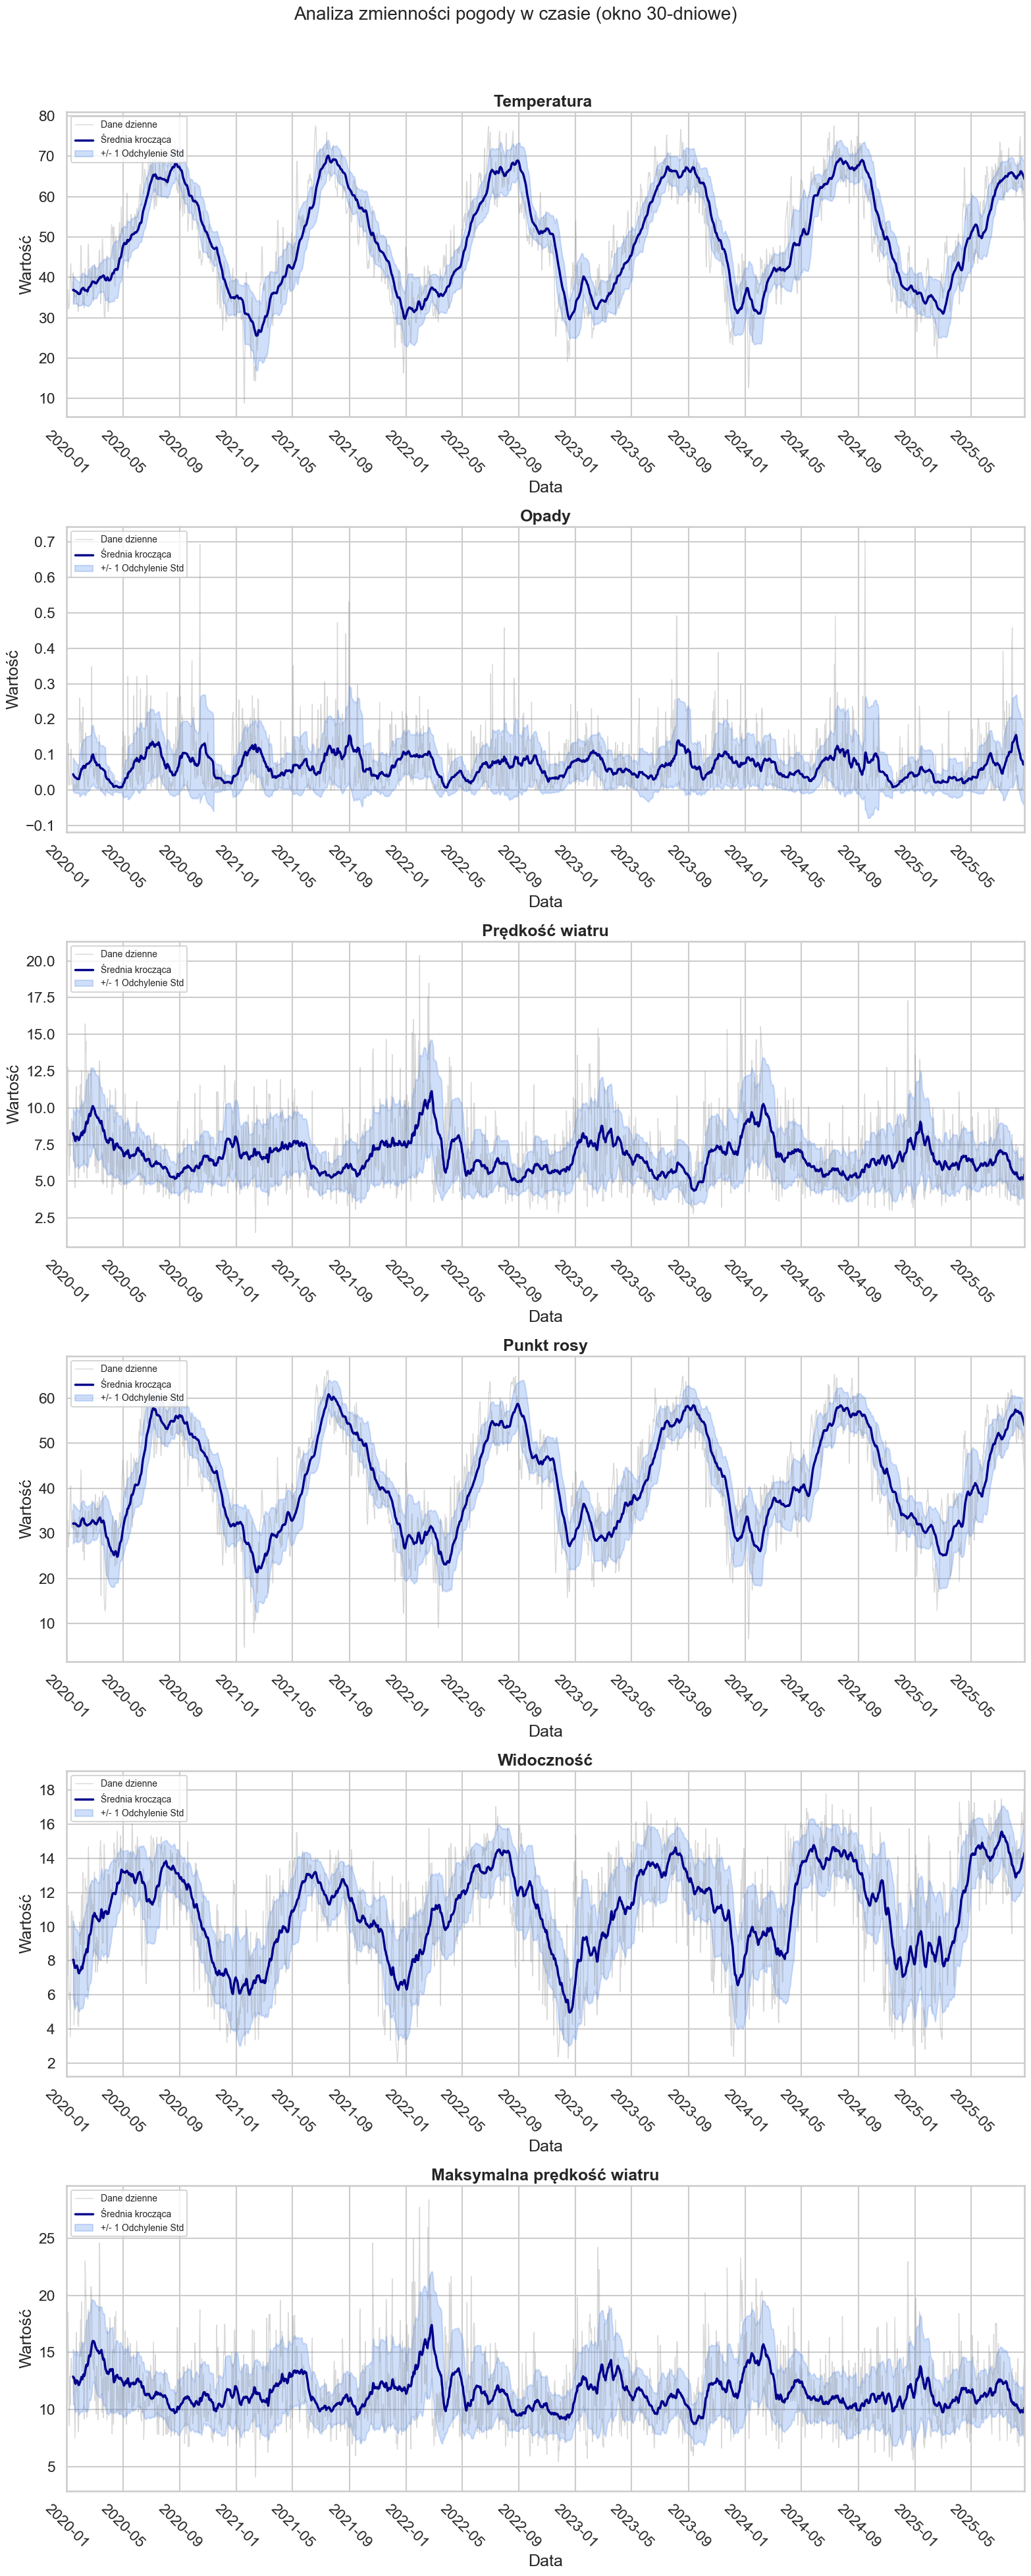

In [15]:
sns.set_theme(style="whitegrid", context="talk")


fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(16,40))
fig.suptitle('Analiza zmienności pogody w czasie (okno 30-dniowe)', fontsize=20, y=0.98)

axes = axes.flatten()


variables = ['temp', 'prcp', 'wdsp', 'dewp', 'visib', 'mxpsd']
titles = [
    'Temperatura ',
    'Opady',
    'Prędkość wiatru',
    'Punkt rosy',
    'Widoczność',
    'Maksymalna prędkość wiatru'
]

for i, var in enumerate(variables):
    ax = axes[i]


    sns.lineplot(data=df, x=df.index, y=var, ax=ax, color='gray', alpha=0.3, linewidth=1, label='Dane dzienne')


    sns.lineplot(data=df, x=df.index, y=f'{var}_rolling_mean', ax=ax, color='darkblue', linewidth=2.5, label='Średnia krocząca')


    ax.fill_between(
        df.index,
        df[f'{var}_rolling_mean'] - df[f'{var}_rolling_std'],
        df[f'{var}_rolling_mean'] + df[f'{var}_rolling_std'],
        color='cornflowerblue', alpha=0.3, label='+/- 1 Odchylenie Std'
    )
    ax.set_xlim(df.index.min(), df.index.max())
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,5,9]))
    ax.set_title(titles[i], fontweight='bold')
    ax.set_xlabel('Data')
    ax.set_ylabel('Wartość')
    ax.legend(loc='upper left', fontsize=10)
    ax.tick_params(axis='x',rotation=-45)

plt.tight_layout()
fig.subplots_adjust(top=0.94)
plt.show()

## Misja dodatkowa -Szeregi czasowe:

Analiza szeregów czasowych ma na celu zbadanie zjawiska na podstawie zachodzących zmian w czasie u mierzalnych wartości. Model buduje się w oparciu o część systematyczną, tj. trendy oraz wahania cykliczne i sezonowe. Ewentualne szumy i wahania przypadkowe nie są uwzględniane.

Wykorzystaj co najmniej dwie różne metody analizy szeregów czasowych, aby zbadać 5 przypadków rozważanych w części 1.
 Możesz wykorzystać m.in.: średnią ruchomą lub inne metody wygładzania, analizę trendu (np. regresję względem czasu), analizę zmian między kolejnymi okresami (np. różnice lub zmiany procentowe), dekompozycję szeregu czasowego lub inne wybrane podejście. Dobierz metody adekwatnie do charakteru danych i liczby dostępnych obserwacji.

Przygotuj wykresy umożliwiające porównanie wyników uzyskanych różnymi metodami. Zwróć uwagę na czytelność wizualizacji oraz możliwość interpretacji wyników. Przedstaw wnioski.


## Część 3:

Analiza regresji pozwala na przewidzenie nieznanych wartości na podstawie innych, które są znane. Jest to metoda statystyczna, która opisuje współzmienności kilku zmiennych przez dopasowanie do nich odpowiedniej funkcji. Model regresji liniowej zakłada liniową zależność między zmienną niezależną (np. czasem), a zmienną zależną (np. temperaturą).

Przygotuj dane treningowe w interesującym Cię okresie czasu oraz dane testowe. Jednostką analizy powinny być obserwacje porównywalne w czasie. Zastosuj analizę regresji, aby przewidzieć wartości w kolejnych okresach następujących po wybranym okresie treningowym. Użyj modelu regresji liniowej, gdzie zmienną niezależną będzie czas, a zmienną zależną:

1. temperatura,

2. opady,

3. prędkość wiatru,

4.  3 inne różne informacje, które uznasz za istotne, w tym co najmniej jedna zmienna związana z rolnictwem.

Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności. Przeanalizuj otrzymane wizualizacje. Zastanów się nad uzyskanymi wynikami np. czy model liniowy dobrze oddaje kierunek zmian, czy wyniki są spójne dla różnych zmiennych, czy zmiana zakresu danych treningowych wpływa na wynik modelu, czy uzyskane prognozy są realistyczne w kontekście analizowanego zjawiska.

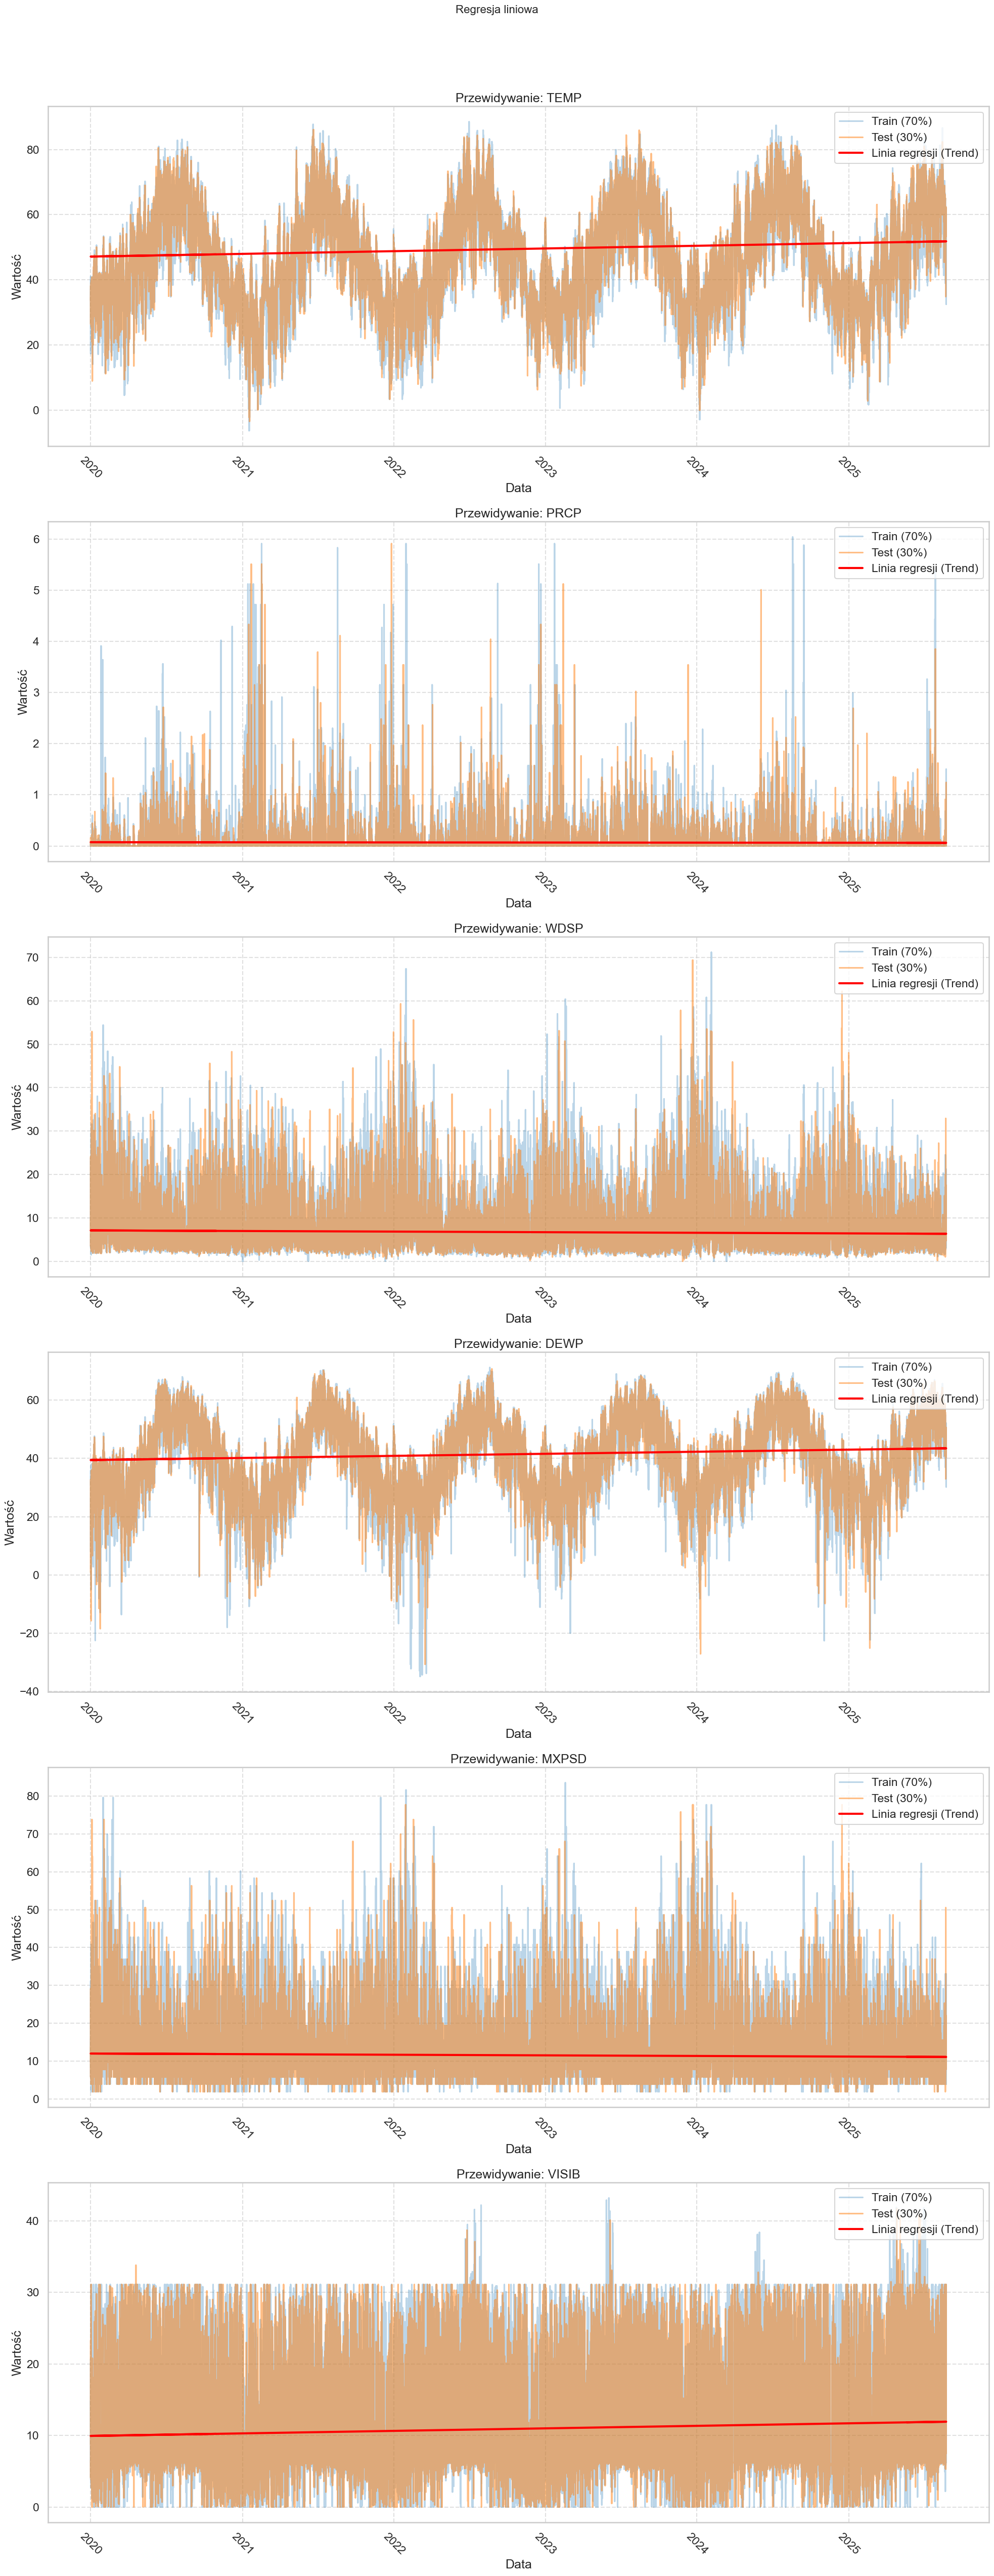

In [17]:
df = pd.read_csv('data/data_5_years_imputed.csv')
df['date'] = pd.to_datetime(df['date'])

df['time_idx'] = (df['date'] - df['date'].min()).dt.days

target_vars = ['temp', 'prcp', 'wdsp', 'dewp', 'mxpsd', 'visib']

X_train, X_test = train_test_split(df, test_size=.3, random_state=42)

X_train = X_train.sort_values('date')
X_test = X_test.sort_values('date')

fig, axes = plt.subplots(6, 1, figsize=(20, 50))
fig.suptitle("Regresja liniowa", fontsize=16, y=1.02)
axes = axes.flatten()

models = {}

for i, var in enumerate(target_vars):
    model = LinearRegression()

    model.fit(X_train[['time_idx']], X_train[var])
    models[var] = model

    df[f'{var}_trend'] = model.predict(df[['time_idx']])

    ax = axes[i]

    ax.plot(X_train['date'], X_train[var], color='#1f77b4', alpha=0.3, label='Train (70%)')

    ax.plot(X_test['date'], X_test[var], color='#ff7f0e', alpha=0.5, label='Test (30%)')

    ax.plot(df['date'], df[f'{var}_trend'], color='red', linewidth=3, label='Linia regresji (Trend)')

    ax.set_title(f'Przewidywanie: {var.upper()}')
    ax.set_xlabel('Data')
    ax.set_ylabel('Wartość')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=-45)

plt.tight_layout()
plt.show()

## Misja dodatkowa - Regresja wielomianowa:

Brak polecenia

C:\Users\dorot\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


ValueError: X has 1 features, but LinearRegression is expecting 7 features as input.

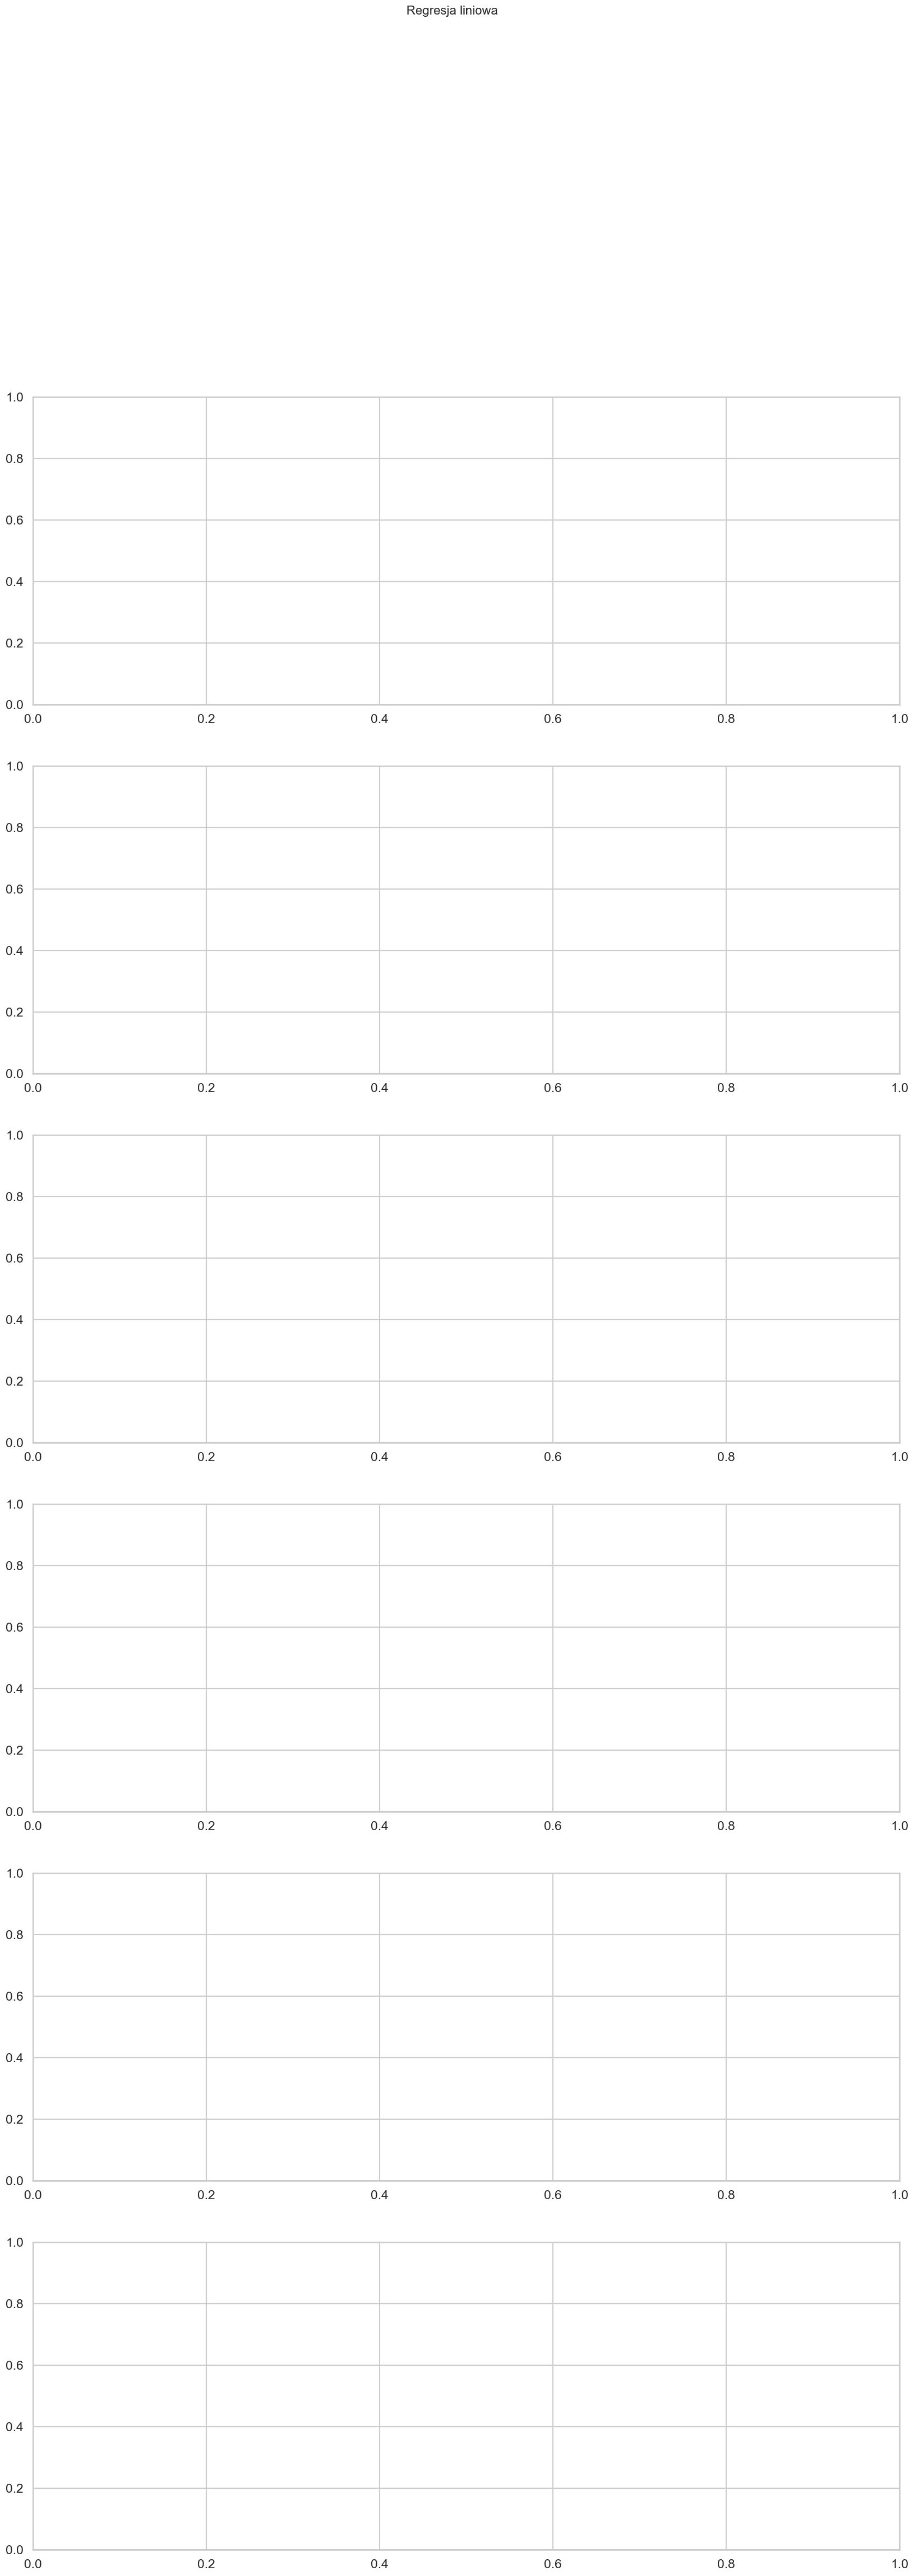

In [23]:
df = pd.read_csv('data/data_5_years_imputed.csv')
df['date'] = pd.to_datetime(df['date'])

df['time_idx'] = (df['date'] - df['date'].min()).dt.days

target_vars = ['temp', 'prcp', 'wdsp', 'dewp', 'mxpsd', 'visib']

X_train, X_test = train_test_split(df, test_size=.3, random_state=42)

X_train = X_train.sort_values('date')
X_test = X_test.sort_values('date')

fig, axes = plt.subplots(6, 1, figsize=(20, 50))
fig.suptitle("Regresja liniowa", fontsize=16, y=1.02)
axes = axes.flatten()

models = {}

for i, var in enumerate(target_vars):
    feature = PolynomialFeatures(degree = 6)

    model = LinearRegression()
    poly_features = feature.fit_transform(X_train[['time_idx']])
    model.fit(poly_features, X_train[var])
    models[var] = model

    df[f'{var}_trend'] = model.predict(df[['time_idx']])

    ax = axes[i]

    ax.plot(X_train['date'], X_train[var], color='#1f77b4', alpha=0.3, label='Train (70%)')

    ax.plot(X_test['date'], X_test[var], color='#ff7f0e', alpha=0.5, label='Test (30%)')

    ax.plot(df['date'], df[f'{var}_trend'], color='red', linewidth=3, label='Linia regresji (Trend)')

    ax.set_title(f'Przewidywanie: {var.upper()}')
    ax.set_xlabel('Data')
    ax.set_ylabel('Wartość')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=-45)

plt.tight_layout()
plt.show()

## Część 5:

Porównanie zmian badanych zjawisk w różnych krajach pozwala lepiej zrozumieć wpływ czynników geograficznych i środowiskowych.

Wybierz minimum 2 kraje, które ze sobą porównasz. Kryterium wyboru powinno umożliwiać zauważenie różnic (np. położenie geograficzne, warunki klimatyczne, struktura produkcji rolnej). Preferowany jest taki wybór, aby móc porównać kraje położone w różnych częściach świata (np. jeden z półkuli północnej, drugi z południowej). Przygotuj porównywalne dane dla wybranych krajów w tym samym okresie czasu.

Zbuduj model regresji liniowej dla każdego kraju, w którym zmienną niezależną będzie czas, a zmiennymi zależnymi:

5.1. temperatura,

5.2. opady,

5.3. prędkość wiatru,

5.4. 3 inne różne informacje, które uznasz za istotne, w tym co najmniej jedna zmienna związana z rolnictwem..

Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi, itp.). Przeanalizuj otrzymane wizualizacje. Zastanów się czy obserwowane zależności są podobne dla różnych krajów, jakie czynniki mogą tłumaczyć różnice, czy wyniki są spójne z charakterystyką wybranych krajów, czy porównanie jest wiarygodne przy przyjętym sposobie reprezentacji danych.